**Can machine learning identify customers who are most likely to respond positively to a bank marketing campaign?**

Using the Bank Market data set we are going to try and predict which customer wil most likely respond to marketing to help determineing which customers to call.

This will enable the Sales and Marketing teams to more effectively target customers who are most likely to respond, ultimately increasing revenue through higher conversion rates while reducing time spent following up with unresponsive customers.


In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [2]:
#Load the dataset
df = pd.read_csv(r'C:\Users\Tech\Documents\Bank Marketing\bank-full data.csv')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


Let's get the meanings of our columns so that we can understand what we are working with.
- age - numerical
- job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student","blue-collar","self-employed","retired","technician","services")
- marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
- education (categorical: "unknown","secondary","primary","tertiary")
- default: has credit in default? (binary: "yes","no")
- balance: average yearly balance, in euros (numeric)
- housing: has housing loan? (binary: "yes","no")
- loan: has personal loan? (binary: "yes","no")
- contact: contact communication type (categorical: "unknown","telephone","cellular")
- day: last contact day of the month (numeric)
- month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")
- duration: last contact duration, in seconds (numeric)
- campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
- pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
- previous: number of contacts performed before this campaign and for this client (numeric)
- poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")
- y - has the client subscribed a term deposit? (binary: "yes","no")



In [8]:
df.columns

Index(['age', 'employment_type', 'marital_status', 'education',
       'credit_default', 'average_yearly_balance', 'housing_loan',
       'personal_loan', 'contact_type', 'last_contact_day',
       'last_contact_month', 'last_contact_duration', 'campaign_contacts',
       'days_since_last_campaign_contact', 'previous_contacts_before_campaign',
       'previous_outcome', 'subscribed_to_term_deposit'],
      dtype='str')

In [7]:
#Change the column names to make is easier to work with
df.columns = [
    'age',
    'employment_type',
    'marital_status',
    'education',
    'credit_default',
    'average_yearly_balance',
    'housing_loan',
    'personal_loan',
    'contact_type',
    'last_contact_day',
    'last_contact_month',
    'last_contact_duration',
    'campaign_contacts',
    'days_since_last_campaign_contact',
    'previous_contacts_before_campaign',
    'previous_outcome',
    'subscribed_to_term_deposit'
    ]

In [10]:
df.tail()

,age,employment_type,marital_status,education,credit_default,average_yearly_balance,housing_loan,personal_loan,contact_type,last_contact_day,last_contact_month,last_contact_duration,campaign_contacts,days_since_last_campaign_contact,previous_contacts_before_campaign,previous_outcome,subscribed_to_term_deposit
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


Performing EDA to understand our data better.

In [11]:
#check to see how imbalanced our target variable is
df["subscribed_to_term_deposit"].value_counts(normalize=True) * 100

subscribed_to_term_deposit
no     88.30152
yes    11.69848
Name: proportion, dtype: float64

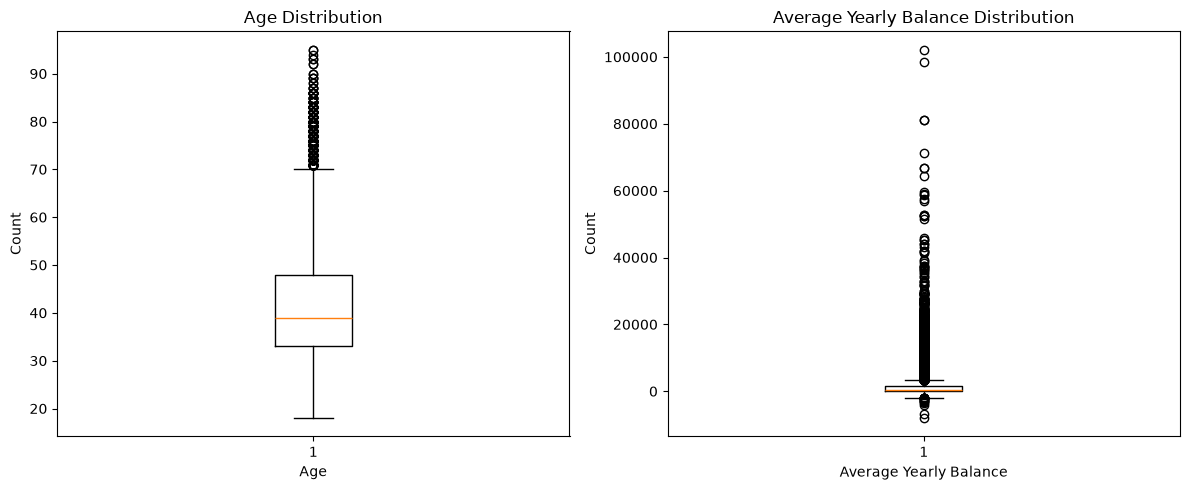

In [12]:
#Check the distribution of age and average yearly balance using boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age
axes[0].boxplot(df["age"], label=["Age"])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Average yearly balance
axes[1].boxplot(df["average_yearly_balance"], label=["Average Yearly Balance"])
axes[1].set_title("Average Yearly Balance Distribution")
axes[1].set_xlabel("Average Yearly Balance")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

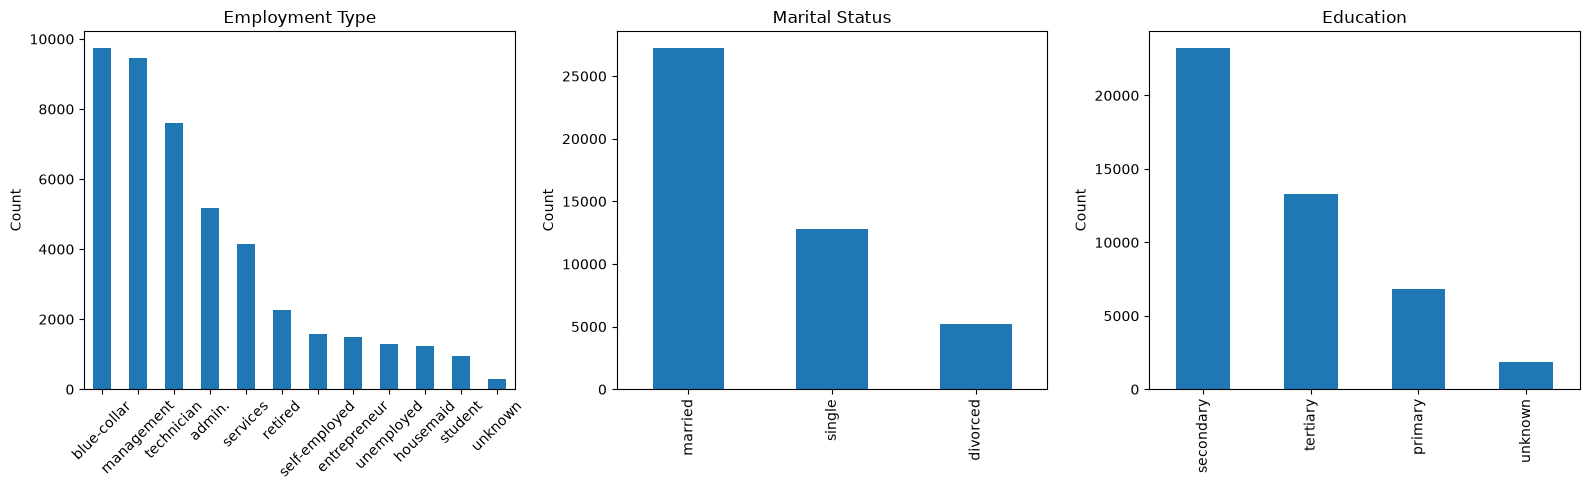

In [13]:
#Check the distribution of categorical variables using bar plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Employment
df["employment_type"].value_counts().plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Employment Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Marital status
df["marital_status"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Marital Status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

# Education
df["education"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Education")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

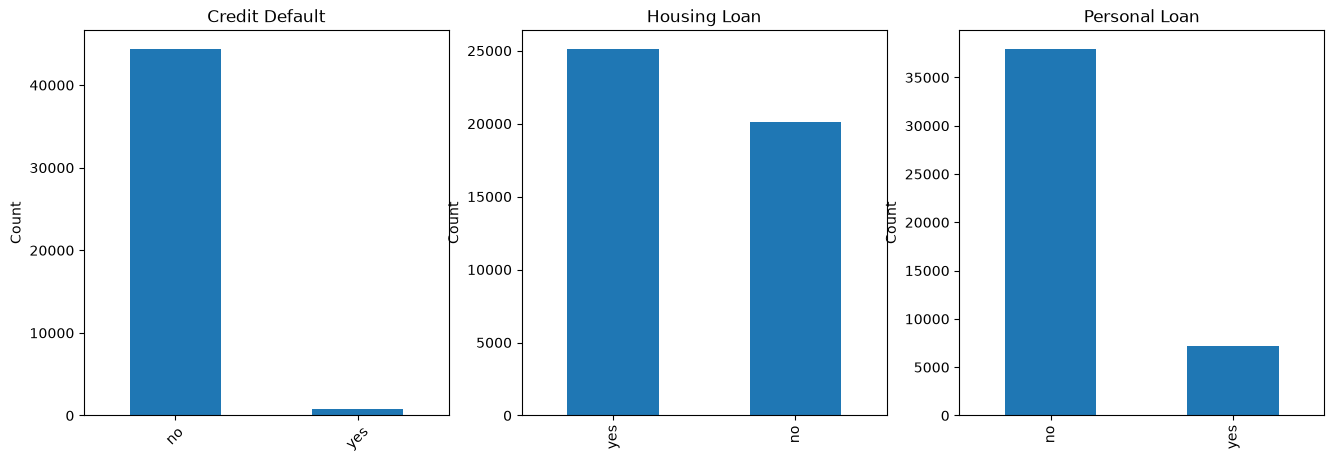

In [35]:
#Check the distribution of credit default, housing loan, and personal loan using bar plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Credit default
df["credit_default"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Credit Default")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Housing loan
df["housing_loan"].value_counts().plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Housing Loan")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

# Personal loan
df["personal_loan"].value_counts().plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Personal Loan")
axes[2].set_xlabel("")
axes[2].set_ylabel("Count")

plt.ylabel("Count")
plt.show()

Now checking the relations between some of the variable with our target variable.

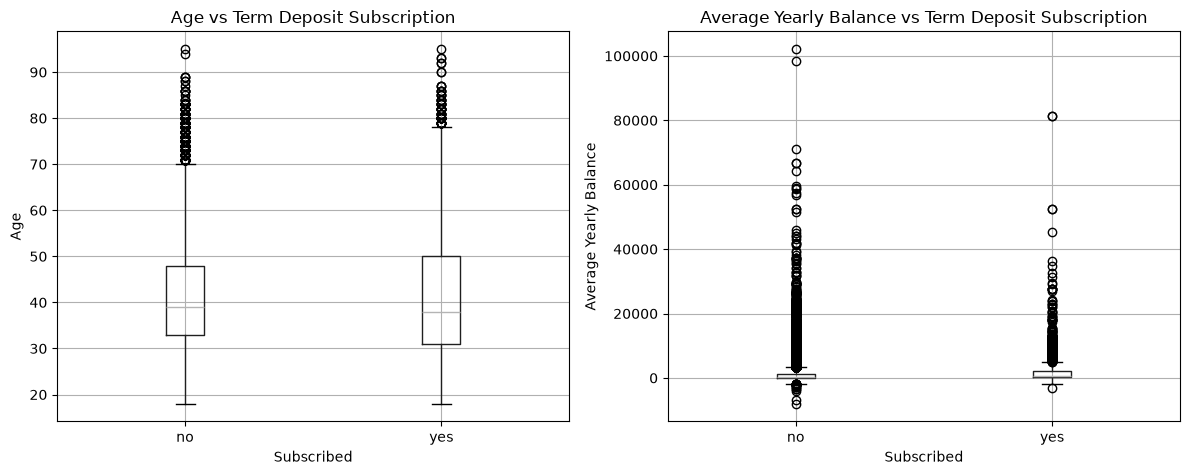

In [15]:
#Starting with some numerical variables, let's see how they relate to our target variable using boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age vs target
df.boxplot(
    column="age",
    by="subscribed_to_term_deposit",
    ax=axes[0]
)
axes[0].set_title("Age vs Term Deposit Subscription")
axes[0].set_xlabel("Subscribed")
axes[0].set_ylabel("Age")

# Average yearly balance vs target
df.boxplot(
    column="average_yearly_balance",
    by="subscribed_to_term_deposit",
    ax=axes[1]
)
axes[1].set_title("Average Yearly Balance vs Term Deposit Subscription")
axes[1].set_xlabel("Subscribed")
axes[1].set_ylabel("Average Yearly Balance")

plt.suptitle("")
plt.tight_layout()
plt.show()

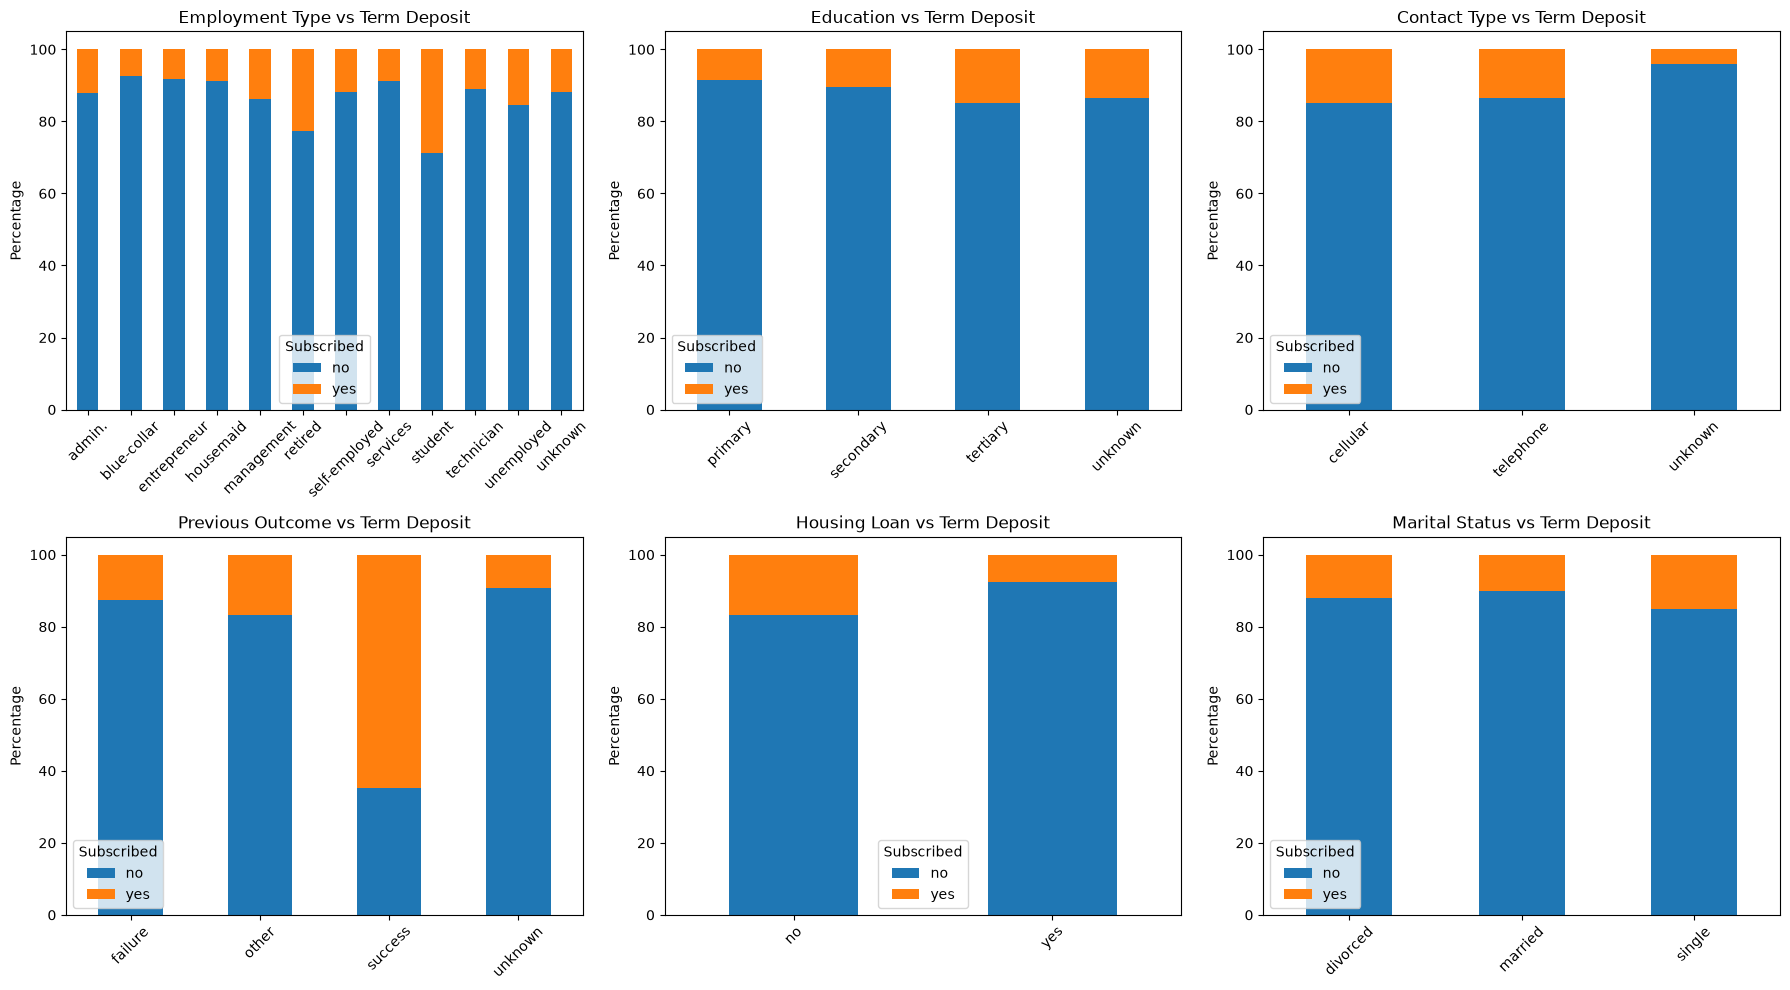

In [17]:
#Then some of the categorical variables, let's see how they relate to our target variable using bar plots
categorical_cols = [
    "employment_type",
    "education",
    "contact_type",
    "previous_outcome",
    "housing_loan",
    "marital_status"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    table = pd.crosstab(
        df[col],
        df["subscribed_to_term_deposit"],
        normalize="index"
    ) * 100

    table.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    ax.set_title(f"{col.replace('_', ' ').title()} vs Term Deposit")
    ax.set_xlabel("")
    ax.set_ylabel("Percentage")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Subscribed")

plt.tight_layout()
plt.show()

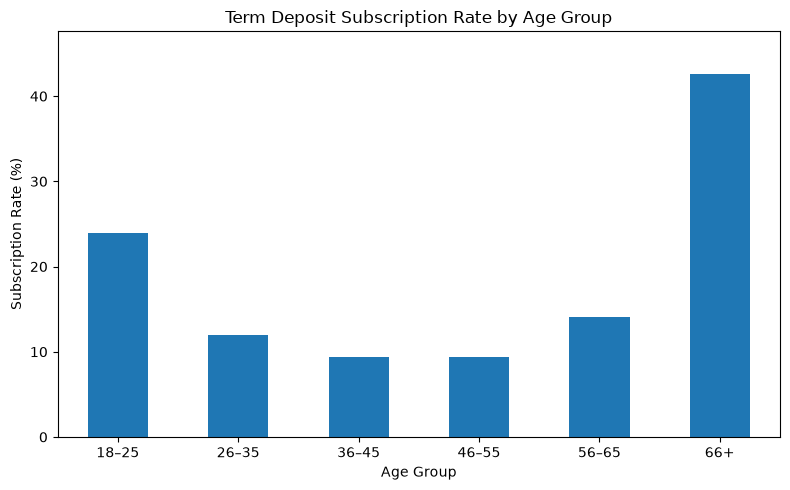

In [18]:
# Create age groups to make it easier to analyze the subscription rate by age group
age_bins = [18, 25, 35, 45, 55, 65, float("inf")]
age_labels = ["18–25", "26–35", "36–45", "46–55", "56–65", "66+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

# Calculate subscription rate
age_subscription = (
    df.groupby("age_group", observed=False)["subscribed_to_term_deposit"]
      .apply(lambda x: (x == "yes").mean() * 100)
)

# Plot
ax = age_subscription.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Term Deposit Subscription Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Subscription Rate (%)")
ax.set_ylim(0, age_subscription.max() + 5)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Identify correlation between numerical variables.
corr = df.select_dtypes(include="number").corr()

corr

,age,average_yearly_balance,last_contact_day,last_contact_duration,campaign_contacts,days_since_last_campaign_contact,previous_contacts_before_campaign
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
average_yearly_balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
last_contact_day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
last_contact_duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign_contacts,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
days_since_last_campaign_contact,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous_contacts_before_campaign,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


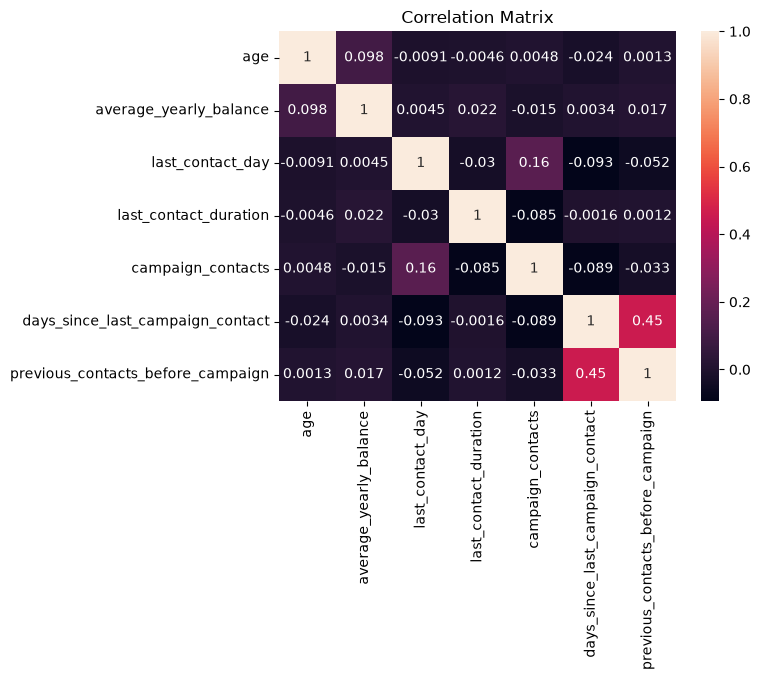

In [20]:
sns.heatmap(corr, annot=True)

plt.title("Correlation Matrix")
plt.show()

In [23]:
df["average_yearly_balance"].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: average_yearly_balance, dtype: float64

In [24]:
df["days_since_last_campaign_contact"].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: days_since_last_campaign_contact, dtype: float64

Since from our data in the column, days since last campaign contact we have -1 which makes it hard for the model to predict correctly, we are adding a few columns to help communicate that -1 meeans that the customer was not previously contacted and not that they were contacted -1 days ago. 

In [27]:
df["previously_contacted"] = (
    df["days_since_last_campaign_contact"] != -1
).astype(int)

In [28]:
df["days_since_last_campaign_contact_clean"] = (
    df["days_since_last_campaign_contact"]
    .replace(-1, 0)
)

In [31]:
df[[
    "days_since_last_campaign_contact",
    "previously_contacted",
    "days_since_last_campaign_contact_clean"
]].head(10)

,days_since_last_campaign_contact,previously_contacted,days_since_last_campaign_contact_clean
0,-1,0,0
1,-1,0,0
2,-1,0,0
3,-1,0,0
4,-1,0,0
5,-1,0,0
6,-1,0,0
7,-1,0,0
8,-1,0,0
9,-1,0,0


In [32]:
df["previously_contacted"].value_counts()

previously_contacted
0    36954
1     8257
Name: count, dtype: int64

In [33]:
df.head(10)

,age,employment_type,marital_status,education,credit_default,average_yearly_balance,housing_loan,personal_loan,contact_type,last_contact_day,last_contact_month,last_contact_duration,campaign_contacts,days_since_last_campaign_contact,previous_contacts_before_campaign,previous_outcome,subscribed_to_term_deposit,age_group,previously_contacted,days_since_last_campaign_contact_clean
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,56–65,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,36–45,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,26–35,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,46–55,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,26–35,0,0
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no,26–35,0,0
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no,26–35,0,0
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no,36–45,0,0
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no,56–65,0,0
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no,36–45,0,0


Performing an investigation to see whether the variable "last_contact_duration" may cause data leakage. In the assusmption that this is amount of time that was taken in the last call before the customer subscribed or did not subscribe. As an insitution this is information that they do not have while trying to predict whether to call them and if the marketing technique will work. 

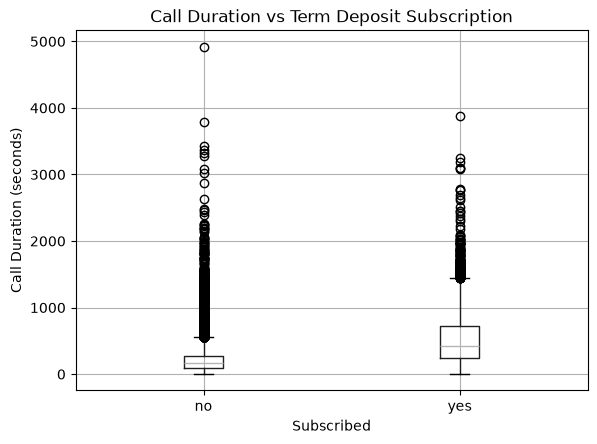

In [34]:
df.boxplot(
    column="last_contact_duration",
    by="subscribed_to_term_deposit"
)

plt.title("Call Duration vs Term Deposit Subscription")
plt.suptitle("")
plt.xlabel("Subscribed")
plt.ylabel("Call Duration (seconds)")
plt.show()

Th graph above proves our assumption right, most the customers whose calls were longer ended up subscribing to the term deposit, therefore this variable may cause data leakage in out model.

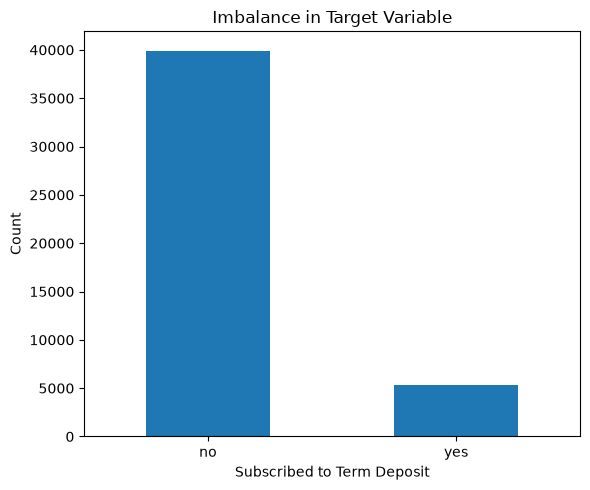

In [36]:
# Check the imbalance in the target variable

plt.figure(figsize=(6, 5))

df["subscribed_to_term_deposit"].value_counts().plot(
    kind="bar"
)

plt.title("Imbalance in Target Variable")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()